Task 1: Use the Graph data structure (NetworkX) to build a realistic simulated transportation network with a minimum of 5 routes and 5 stations per route, ensuring comprehensive connectivity between stations through transfer points. The program must allow users to select the display unit as kilometers or miles from the start, then automatically update the distance labels on the edges based on real-world data from Google/Apple Maps. The final result must ensure geographical accuracy, strictly adhere to the design style template regarding color, circled points, and complete legend (Key) for the entire diagram.

In [34]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [35]:
choice = input("Please enter your choice (1 - Km or 2 - mi): ")
unit_label = "km" if choice == '1' else "mi"
conv_km = 0.0258
conv_mi = conv_km * 0.621371

In [36]:
pos = {
    "Yio Chu Kang": (617, -368), "Ang Mo Kio": (617, -409), "Bishan": (616, -457),
    "Braddell": (617, -484), "Toa Payoh": (617, -524), "Novena": (593, -570), 
    "Newton": (576, -596),
    "Potong Passir": (681, -559), "Woodleigh": (716, -524), "Serangoon": (756, -485), 
    "Kovan": (786, -454), "Hougang": (813, -428),
    "Bartley": (809, -522), "Lorong Chuan": (694, -462), "Marymount": (550, -469), 
    "Caldecott": (504, -493), "Botanic Gardens": (424, -563), "Farrer Road": (397, -615),
    "Sixth Avenue": (320, -533), "Tan Kah Kee": (361, -563), "Stevens": (504, -563),
    "Bright Hill": (482, -403), "Upper Thomson": (504, -450), "Napier": (504, -600),
    }

In [37]:
mrt_data = {
    "North-South Line": {
        "stations": [
            "Yio Chu Kang", "Ang Mo Kio", "Bishan", "Braddell", "Toa Payoh", "Novena", "Newton"
        ],
        "color": "#D42E12"
    },
    "North-East Line": {
        "stations": [
            "Potong Passir", "Woodleigh", "Serangoon", "Kovan", "Hougang"
        ],
        "color": "#9900AA"
    },
    "Circle Line Main": {
        "stations": [ 
            "Bartley", "Serangoon", "Lorong Chuan", "Bishan", "Marymount", "Caldecott",
            "Botanic Gardens", "Farrer Road"
        ],
        "color": "#FA9E0D"
    },
    "Downtown Line": {
        "stations": [ 
            "Sixth Avenue", "Tan Kah Kee", "Botanic Gardens", "Stevens", "Newton" 
        ],
        "color": "#005EC4" 
    },
    "Thomson-East Coast Line": {
        "stations": [
            "Bright Hill", "Upper Thomson", "Caldecott", "Stevens", "Napier"
        ],
        "color": "#734538"
}
    
}

In [38]:
def calculate_distance(point1, point2):
    dx = point1[0] - point2[0]
    dy = point1[1] - point2[1]
    return int(np.sqrt(dx**2 + dy**2))

In [39]:
G = nx.Graph()
edge_labels = {}

In [40]:
station_line_colors = {}

for line_name, info in mrt_data.items():
    active_stations = [s for s in info["stations"] if s in pos]
    line_color = info["color"]
    
    for station in active_stations:
        if station not in station_line_colors:
            station_line_colors[station] = line_color
    
    for i in range(len(active_stations) - 1):
        u = active_stations[i]
        v = active_stations[i+1]
        pixel_dist = calculate_distance(pos[u], pos[v])
        
        dist_km = round(pixel_dist * conv_km, 2)        
        dist_mi = round(pixel_dist * conv_mi, 2)  
        G.add_edge(u, v, color=line_color, km=dist_km, miles=dist_mi)
        
        if (u, v) not in edge_labels and (v, u) not in edge_labels:
            if choice == '1':
                val = dist_km 
            else:
                val = dist_mi
            
            edge_labels[(u, v)] = f"{val}{unit_label}"

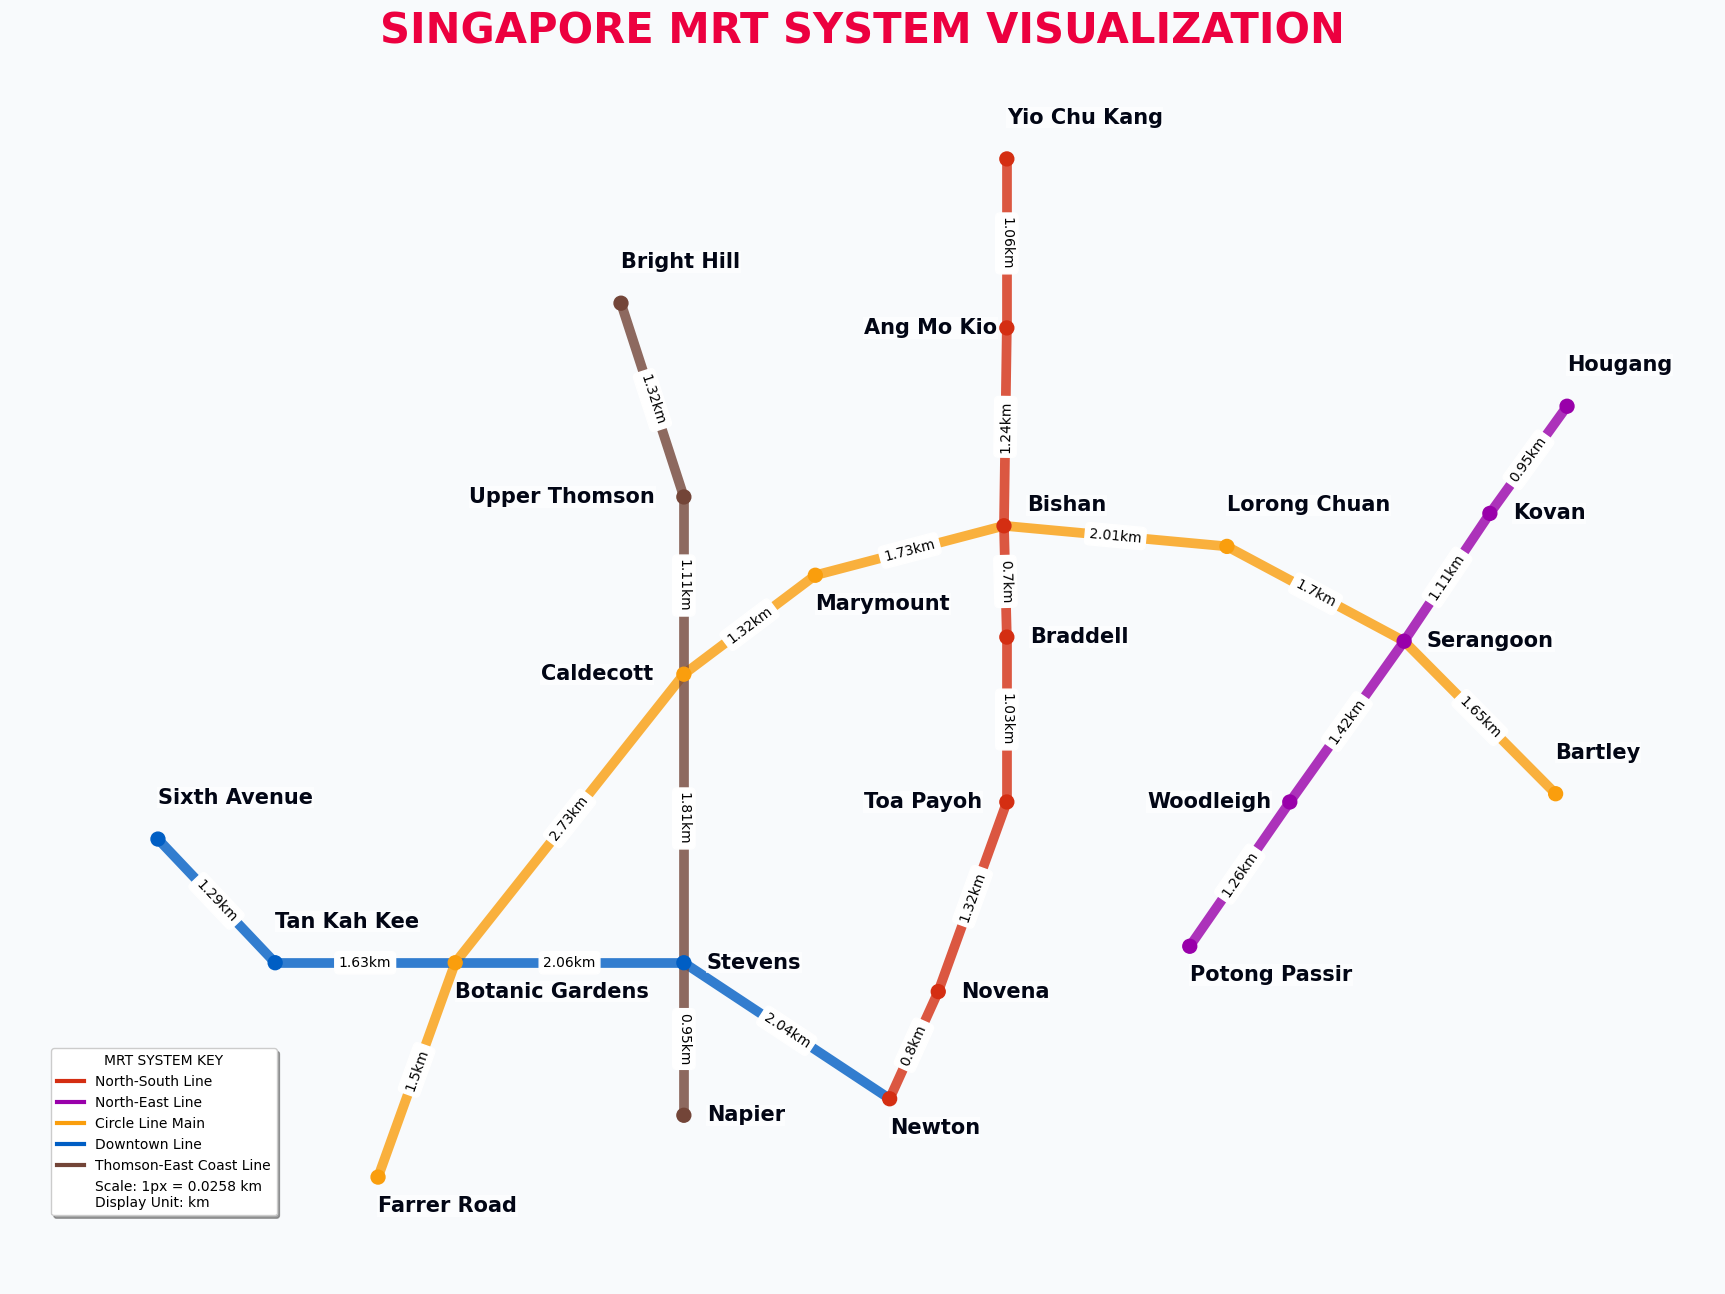

In [41]:
plt.figure(figsize=(22, 16), facecolor="#f8fafc")

edge_colors = [G[u][v]['color'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=7, alpha=0.8)

node_colors = [station_line_colors.get(node, "#020618") for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=100, node_color=node_colors)

label_pos = {}
for name, (x, y) in pos.items():
    if name in ["Napier", "Stevens", "Novena","Braddell","Serangoon","Kovan"]:
        label_pos[name] = (x + 8, y)
        ha_choice = 'left'
    
    elif name in ["Newton","Potong Passir","Botanic Gardens","Marymount","Farrer Road"]:
        label_pos[name] = (x, y - 7)
        ha_choice = 'center'
    
    elif name in ["Caldecott","Toa Payoh","Ang Mo Kio","Woodleigh"]:
        label_pos[name] = (x - 50, y )

    elif name in ["Upper Thomson"]:
        label_pos[name] = (x - 75, y )


    elif name in ["Bishan"]:
        label_pos[name] = (x + 8, y + 5)

    else:
        label_pos[name] = (x, y + 10)
        ha_choice = 'right'

nx.draw_networkx_labels(
        G, 
        label_pos, 
        font_size=15, 
        font_weight='bold', 
        font_color="#020615", 
        horizontalalignment=ha_choice,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5)
    )

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, rotate=True)

for line_name, info in mrt_data.items():
    plt.plot([], color=info["color"], label=line_name, linewidth=3)

scale_text = f"Scale: 1px = {conv_km} km\nDisplay Unit: {unit_label}"
plt.plot([], ' ', label=scale_text)

plt.legend(title="MRT SYSTEM KEY", loc='lower left', bbox_to_anchor=(0.02, 0.05), shadow=True)
plt.title("SINGAPORE MRT SYSTEM VISUALIZATION", color="#ec003f", fontsize=30, fontweight='bold')
plt.axis('off')
plt.show()

Task 2:
- Total network length: Add up all the distances of the edges (in both kilometers and miles).
- Average distance: Divide the total length by the number of edges (in both kilometers and miles).

In [42]:
all_km = [G[u][v]['km'] for u, v in G.edges()]
all_mi = [G[u][v]['miles'] for u, v in G.edges()]

In [43]:
num_edges = len(all_km)

total_km = sum(all_km)
total_mi = sum(all_mi)

avg_km = total_km / num_edges
avg_mi = total_mi / num_edges

In [44]:
print("MRT NETWORK STATISTICS")
print("-" * 40)
print(f"Total network length: {total_km:.3f} km ({total_mi:.3f} miles)")
print(f"Average distance between stations: {avg_km:.2f} km ({avg_mi:.2f} miles)")

MRT NETWORK STATISTICS
----------------------------------------
Total network length: 35.740 km (22.210 miles)
Average distance between stations: 1.43 km (0.89 miles)
